### Gradient Boosting

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    cross_validate,
    learning_curve,
    validation_curve
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
#data loading
data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
df = pd.read_csv(data_url)

print(df.head())

       N      P      K  temperature   humidity        ph    rainfall      crop
0   17.0  136.0  196.0    23.871923  90.499390  5.882156  103.054809     apple
1   49.0   69.0   82.0    18.315615  15.361435  7.263119   81.787105  chickpea
2   74.0   49.0   38.0    23.314104  71.450905  7.488014  164.497037      jute
3  104.0   35.0   28.0    27.510061  50.666872  6.983732  143.995555    coffee
4   23.0   72.0   84.0    19.020613  17.131591  6.920251   79.926981  chickpea


In [3]:
# Separate features and target
feature_col = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[feature_col]
y = df['crop']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

# Note: Gradient Boosting doesn't require feature scaling
# but it can help with numerical stability

  Training set: 1320 samples
  Test set: 330 samples


In [5]:
gb_baseline = GradientBoostingClassifier(
    n_estimators=100,      # Number of boosting stages
    learning_rate=0.1,     # Shrinkage factor
    max_depth=3,           # Maximum depth of trees
    random_state=42        # For reproducibility
)

# Train the model
gb_baseline.fit(X_train, y_train)

# Predictions
y_pred_baseline = gb_baseline.predict(X_test)

# Evaluate
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, average='weighted')
recall_baseline = recall_score(y_test, y_pred_baseline, average='weighted')
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print(f"   Accuracy:  {accuracy_baseline:.4f}")
print(f"   Precision: {precision_baseline:.4f}")
print(f"   Recall:    {recall_baseline:.4f}")
print(f"   F1-Score:  {f1_baseline:.4f}")


   Accuracy:  0.9848
   Precision: 0.9858
   Recall:    0.9848
   F1-Score:  0.9849


In [6]:

param_grid = {
    'n_estimators': [10, 20, 50, 100],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
}

# Create GridSearchCV
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.9826


In [7]:
# Get best model from GridSearchCV
best_model = grid_search.best_estimator_

# Make predictions on test set
y_pred_final = best_model.predict(X_test)

# Calculate metrics
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print(f"   Accuracy final:  {accuracy_final:.4f}")
print(f"   Precision final: {precision_final:.4f}")
print(f"   Recall final:    {recall_final:.4f}")
print(f"   F1-Score final:  {f1_final:.4f}")


   Accuracy final:  0.9879
   Precision final: 0.9890
   Recall final:    0.9879
   F1-Score final:  0.9876


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21]),
 [Text(0, 0, 'apple'),
  Text(0, 1, 'banana'),
  Text(0, 2, 'blackgram'),
  Text(0, 3, 'chickpea'),
  Text(0, 4, 'coconut'),
  Text(0, 5, 'coffee'),
  Text(0, 6, 'cotton'),
  Text(0, 7, 'grapes'),
  Text(0, 8, 'jute'),
  Text(0, 9, 'kidneybeans'),
  Text(0, 10, 'lentil'),
  Text(0, 11, 'maize'),
  Text(0, 12, 'mango'),
  Text(0, 13, 'mothbeans'),
  Text(0, 14, 'mungbean'),
  Text(0, 15, 'muskmelon'),
  Text(0, 16, 'orange'),
  Text(0, 17, 'papaya'),
  Text(0, 18, 'pigeonpeas'),
  Text(0, 19, 'pomegranate'),
  Text(0, 20, 'rice'),
  Text(0, 21, 'watermelon')])

<Figure size 800x400 with 0 Axes>

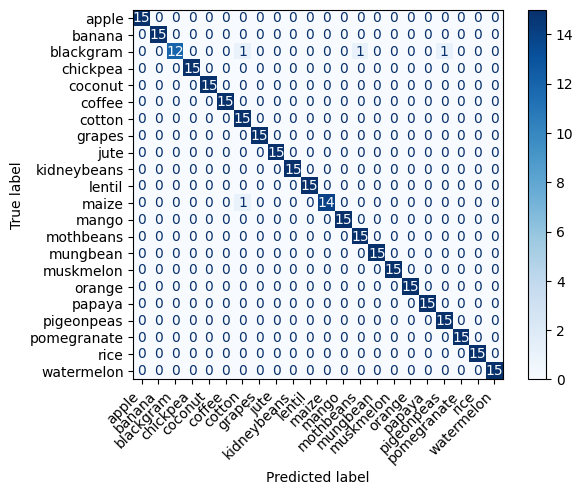

In [8]:
# Visualize confusion matrix
plt.figure(figsize=(8, 4))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(cmap='Blues', values_format='d')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)


In [9]:
import joblib
from pathlib import Path

model_obj = globals().get("best_model")
output_path = Path("../../models/gradient_boosting.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")

Saved model to: /media/kushagra/DATA/notebook/crop-recommendation-ml-system/models/gradient_boosting.pkl


In [10]:
sample_input = [[17.0,  136.0,  196.0,    23.871923,  90.499390,  5.882156,  103.054809]]  # N, P, K, temperature, humidity, ph, rainfall
prediction = best_model.predict(sample_input)
print(f"Predicted crop: {le.inverse_transform([prediction[0]])[0]}")

Predicted crop: apple


/media/kushagra/DATA/notebook/crop-recommendation-ml-system/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
